### [도구란?](https://huggingface.co/learn/agents-course/ko/unit1/tools)

In [ ]:
class Tool:
    """
    재사용 가능한 코드 조각(도구)을 나타내는 클래스입니다.
    
    Attributes(속성):
        name (str): 도구의 이름
        description (str): 도구가 수행하는 작업에 대한 설명
        func (callable): 도구가 호출하는 함수
        arguments (list): 함수의 입력값 리스트
        outputs (str 또는 list): 함수의 출력값
    """
    def __init__(self, 
                 name: str, 
                 description: str, 
                 func: callable, 
                 arguments: list,
                 outputs: str):
        self.name = name
        self.description = description
        self.func = func
        self.arguments = arguments
        self.outputs = outputs

    def to_string(self) -> str:
        """
        도구의 속성을 문자열로 변환하여 반환합니다.
        name, description, arguments, outputs을 포함합니다.
        """
        args_str = ", ".join([
            f"{arg_name}: {arg_type}" for arg_name, arg_type in self.arguments
        ])
        
        return (
            f"Tool Name: {self.name},"
            f" Description: {self.description},"
            f" Arguments: {args_str},"
            f" Outputs: {self.outputs}"
        )

    def __call__(self, *args, **kwargs):
        """
        저장된 함수(callable)를 주어진 입력값으로 실행합니다.
        """
        return self.func(*args, **kwargs)

In [5]:
import inspect

def tool(func):
    """
    주어진 함수를 기반으로 Tool 인스턴스를 생성하는 데코레이터입니다.
    """
    # 함수의 서명(signature) 가져오기
    signature = inspect.signature(func)
    
    # 입력 인자 추출 (param_name, param_annotation)
    arguments = []
    for param in signature.parameters.values():
        annotation_name = (
            param.annotation.__name__ 
            if hasattr(param.annotation, '__name__') 
            else str(param.annotation)
        )
        arguments.append((param.name, annotation_name))
    
    # 리턴값 타입 결정
    return_annotation = signature.return_annotation
    if return_annotation is inspect._empty:
        outputs = "No return annotation"
    else:
        outputs = (
            return_annotation.__name__ 
            if hasattr(return_annotation, '__name__') 
            else str(return_annotation)
        )
    
    # 함수의 docstring을 설명으로 사용
    description = func.__doc__ or "No description provided."
    
    # 함수명을 도구 이름으로 사용
    name = func.__name__
    
    # Tool 인스턴스를 리턴
    return Tool(
        name=name, 
        description=description, 
        func=func, 
        arguments=arguments, 
        outputs=outputs
    )

In [6]:
@tool
def calculator(a: int, b: int) -> int:
    """두 정수를 곱하세요"""
    return a * b

print(calculator.to_string())

Tool Name: calculator, Description: 두 정수를 곱하세요, Arguments: a: int, b: int, Outputs: int


### [Re-Act](https://huggingface.co/learn/agents-course/ko/unit1/thoughts)

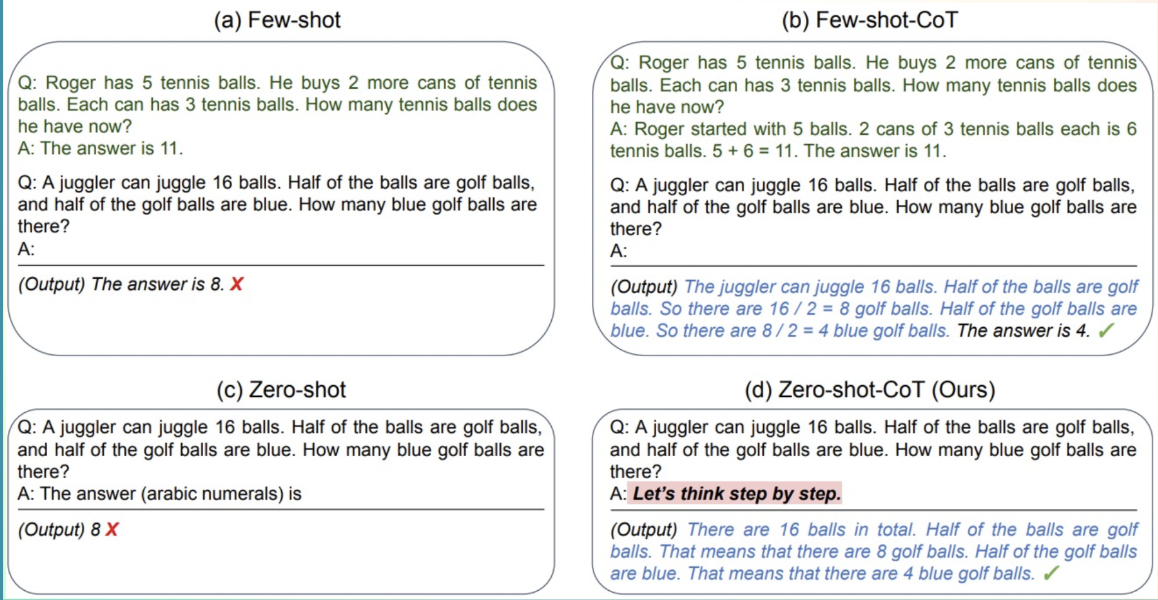

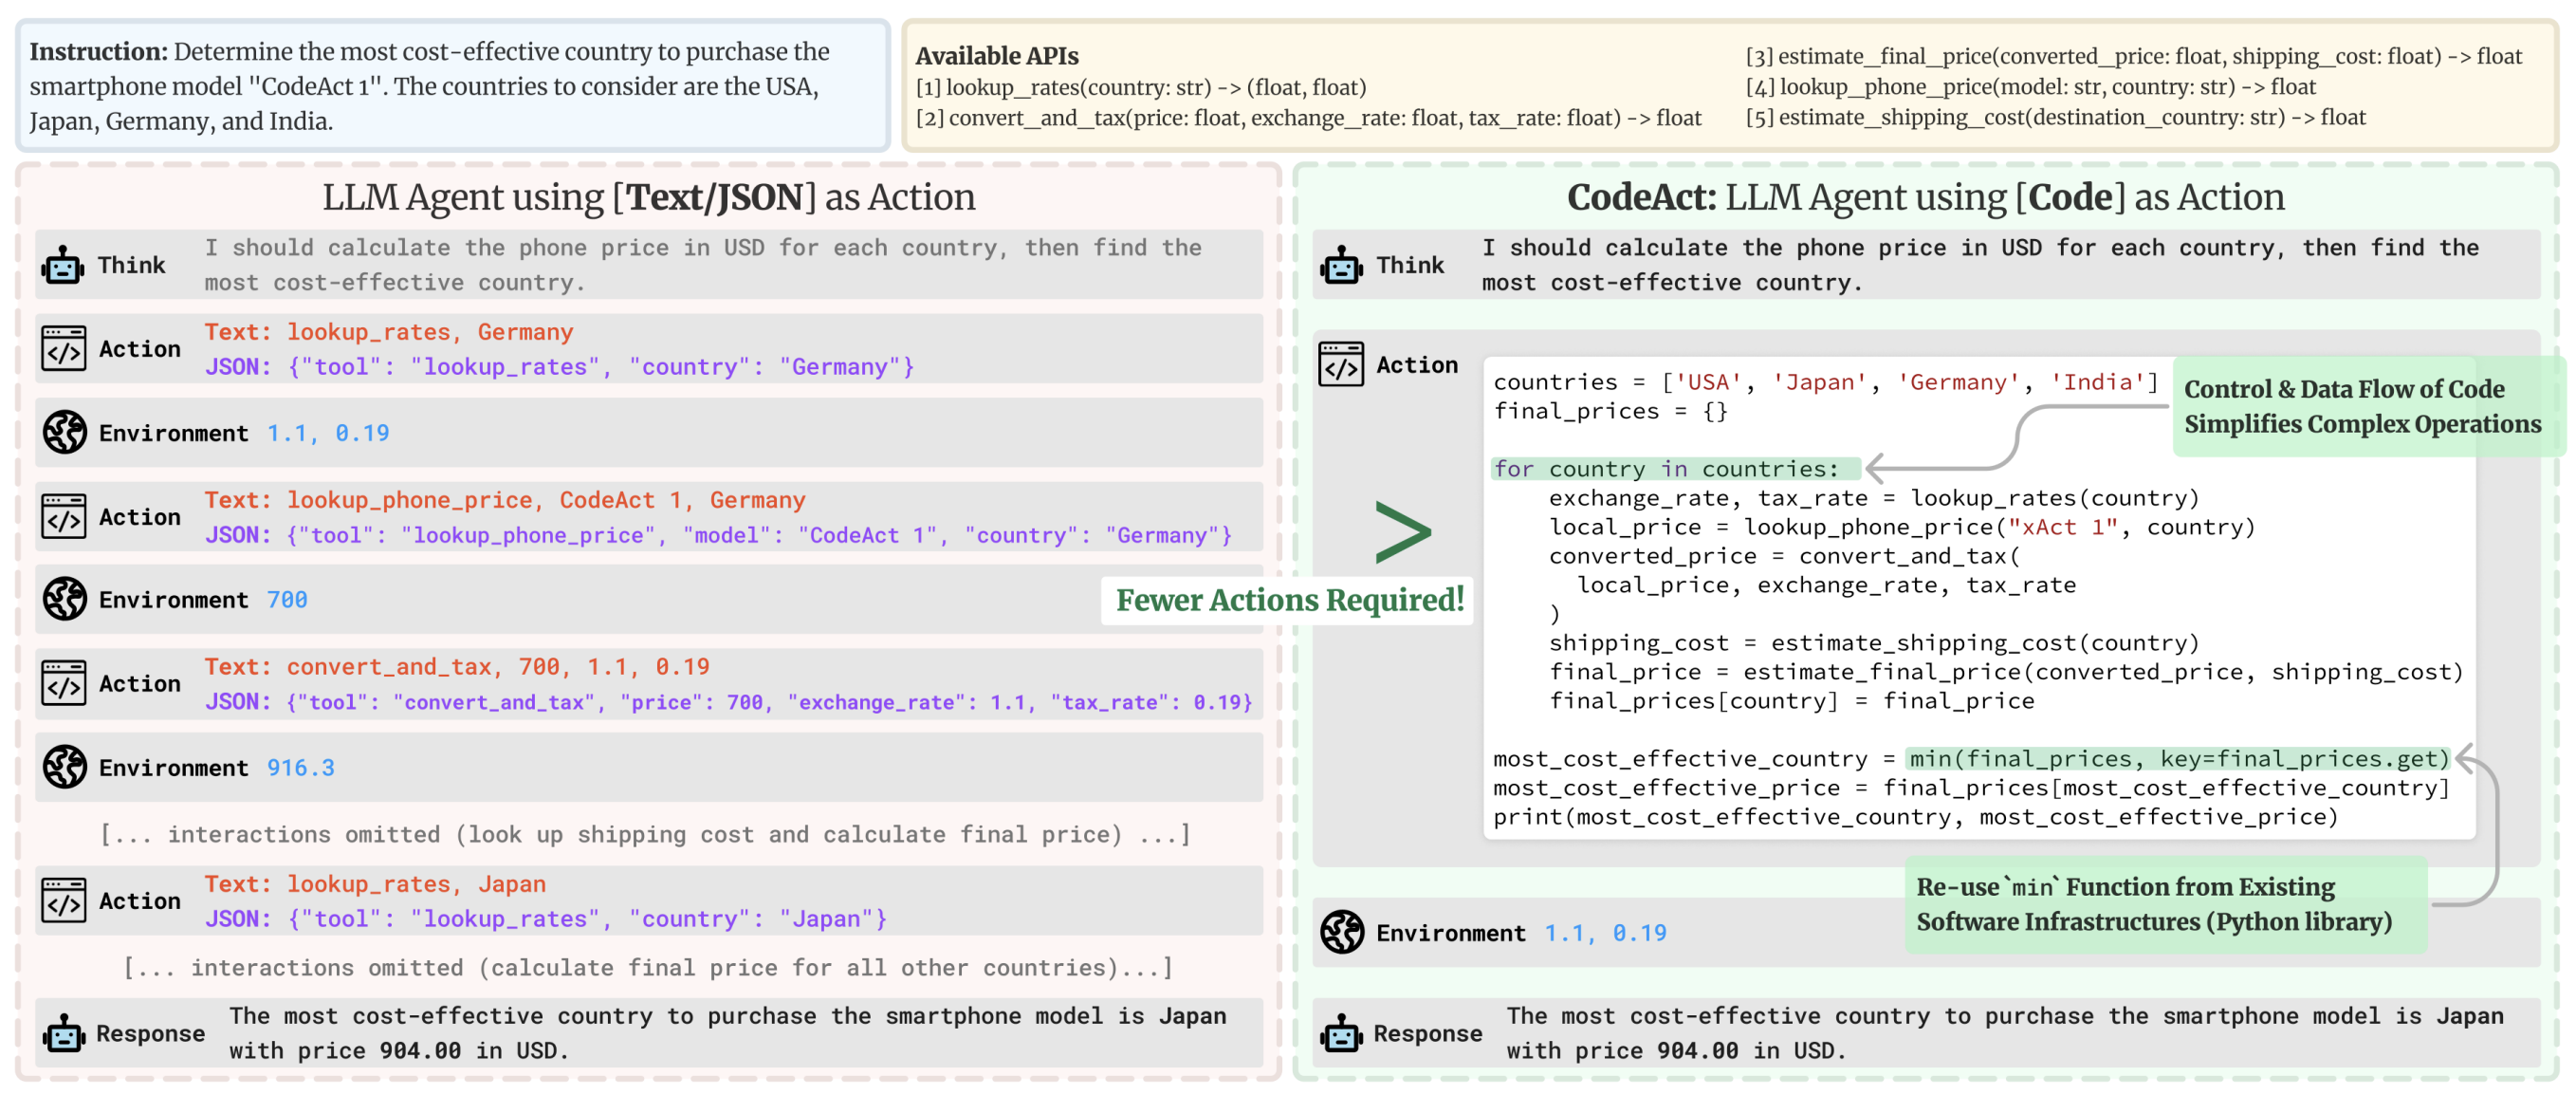